### Parte 2

Realizar un acercamiento a una base de datos de señales ECG, disponible en:
https://figshare.com/collections/ChapmanECG/4560497. Identificar sus principales características y
realizando un análisis estadístico que permita determinar si existen diferencias significativas entre los grupos
de sujetos con diferentes tipos de arritmias (utilizar los datos disponibles en los archivos filtrados
ECGDataDenoised.zip).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np


#### **Tipos de ritmos de los latidos cardiacos presentes en los datos**
Estas arritmias se encuentran en el canal 2 de "Diagnostics" la columna se llama "Rhythm"

- **SB - (Sinus Bradycardia):** ritmo cardíaco en el que el corazón late a menos de 60 latidos por minuto (Tipo de arritmia en personas con excelente condicion fisica). Sí, puede clasificarse como una alteración del ritmo, aunque no siempre se considera una arritmia patológica.

- **SR — Ritmo sinusal:** Es el ritmo cardíaco normal generado por el nodo sinusal, con activación ordenada de las aurículas y los ventrículos. No es una arritmia.

- **AFIB - Atrial Fibrillation:** La fibrilación auricular es la alteración del ritmo cardíaco o arritmia más común, la cual hace que las cavidades superiores del corazón latan de forma rápida, caótica e irregular. Sí, es una arritmia.

- **ST — Taquicardia sinusal:** Es un ritmo originado en el nodo sinusal con una frecuencia cardíaca superior a 100 latidos por minuto, generalmente como respuesta a ejercicio, estrés, fiebre u otras condiciones. No necesariamente es una arritmia; puede ser una respuesta fisiológica normal.

- **AF	Atrial Flutter:** es un tipo de arritmia  en el cual las cavidades superiores del corazón (las aurículas) laten de manera muy rápida y organizada, por lo general entre 240 y 340 latidos por minuto. Sí, es una arritmia.

- **SI — Irregularidad sinusal:** Es una variación del intervalo entre los latidos que mantiene su origen en el nodo sinusal; puede presentarse normalmente, por ejemplo, relacionada con la respiración. Generalmente no se considera una arritmia patológica.

- **SVT — Taquicardia supraventricular:** Es un ritmo cardíaco acelerado cuyo origen se encuentra por encima de los ventrículos, en las aurículas o en la región auriculoventricular. Sí, es una arritmia.

- **AT — Taquicardia auricular:** Es una taquicardia cuyo origen se encuentra en un foco anormal dentro de las aurículas, diferente al nodo sinusal. Sí, es una arritmia.

- **AVNRT — Taquicardia por reentrada intranodal auriculoventricular:** Es una taquicardia causada por un circuito eléctrico de reentrada dentro o cerca del nodo auriculoventricular, que provoca latidos rápidos. Sí, es una arritmia.

- **AVRT — Taquicardia por reentrada auriculoventricular:** Es una taquicardia producida por un circuito eléctrico que utiliza una vía accesoria entre las aurículas y los ventrículos. Sí, es una arritmia.

- **SAAWR — Ritmo auricular errante (marcapasos auricular migratorio):** Es un ritmo en el que el sitio que genera los impulsos eléctricos cambia entre diferentes zonas de las aurículas, produciendo variaciones en la morfología de la onda P. Generalmente no se considera una arritmia peligrosa y puede ser una variante benigna del ritmo cardíaco.


#### **Obtención de datos**

In [ ]:
#Extrapolado a muchos pacientes 


#   Ubicación de los archivos
# Carpeta donde se encuentran los archivos ECG
SIGNALS_DIR = Path(
    r"C:\Documentos\Octavo semestre 2026-2\Bioseñales\laboratorio\ECGDataDenoised\ECGDataDenoised"
)


# Excel donde se encuentra la metadata de cada paciente (Archivo de diagnóstico)
DIAGNOSTICS_PATH = Path(r"C:\Documentos\Octavo semestre 2026-2\Bioseñales\laboratorio\ECGDataDenoised\Diagnostics.xlsx")



#   Parámetros de los registros ECG
# Frecuencia de muestreo: 500 muestras por segundo segun base de datos
FS = 500  # Hz

# Canales y sus derivaciones
LEADS = [
    "I", "II", "III", "aVR", "aVL", "aVF",
    "V1", "V2", "V3", "V4", "V5", "V6"
]



#   Leer Diagnostics.xlsx
diagnostics = pd.read_excel(DIAGNOSTICS_PATH)



#   Identificar la segunda columna
# La segunda columna contiene la condición/diagnóstico (Arritmias)
diagnosis_column = diagnostics.columns[1]

print("Columna utilizada para identificar el diagnóstico:")
print(diagnosis_column)


#  Pacientes totales
# Se identifica el numero total de pacientes y registros en la base de datos
FILENAME_ALL = diagnostics["FileName"].astype(str).tolist()

print(f"\nNúmero total de pacientes/registros: {len(FILENAME_ALL)}")


Columna utilizada para identificar el diagnóstico:
Rhythm

Número total de pacientes/registros: 10646


---------------------------------------------

Se analizan la cantidd de datos que hay para cada tipo de arritmia

In [33]:
# ARRITMIA SB

sb_diagnostics = diagnostics[
    diagnostics[diagnosis_column]
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("SB")
].copy()
#Esta parte filtra diagnostics y conserva únicamente las filas cuyo diagnóstico sea "SB"


FILENAME_SB = sb_diagnostics["FileName"].astype(str).tolist()
#De los registros que quedaron después del filtro, toma únicamente la columna FileName.
# .tolist() convierte esa columna en una lista de Python,
# por lo tanto, FILENAME_SB contiene los nombres de los archivos correspondientes a los registros diagnosticados como SB.


print(f"\nNúmero de pacientes/registros con SB: {len(FILENAME_SB)}")
# len() cuenta cuántos elementos hay en FILENAME_SB

#for i, filename in enumerate(FILENAME_SB, start=1):
    #print(f"{i}. {filename}")
# Recorre la lista de los nombres de los registros en FILENAME_SB y los imprime 


Número de pacientes/registros con SB: 3889


In [38]:
#ARRITMIA SR

SR_diagnostics = diagnostics[
    diagnostics[diagnosis_column]
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("SR")
].copy()



FILENAME_SR = SR_diagnostics["FileName"].astype(str).tolist()


print(f"\nNúmero de pacientes/registros con SR: {len(FILENAME_SR)}")


Número de pacientes/registros con SR: 1826


In [47]:
#ARRITMIA AFIB

AFIB_diagnostics = diagnostics[
    diagnostics[diagnosis_column]
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("AFIB")
].copy()



FILENAME_AFIB = AFIB_diagnostics["FileName"].astype(str).tolist()


print(f"\nNúmero de pacientes/registros con AFIB: {len(FILENAME_AFIB)}")

#for i, filename in enumerate(FILENAME_ST, start=1):
    #print(f"{i}. {filename}")


Número de pacientes/registros con AFIB: 1780


In [32]:
#ARRITMIA ST

ST_diagnostics = diagnostics[
    diagnostics[diagnosis_column]
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("ST")
].copy()



FILENAME_ST = ST_diagnostics["FileName"].astype(str).tolist()


print(f"\nNúmero de pacientes/registros con ST: {len(FILENAME_ST)}")

#for i, filename in enumerate(FILENAME_ST, start=1):
    #print(f"{i}. {filename}")


Número de pacientes/registros con ST: 1568


In [48]:
#ARRITMIA AF

AF_diagnostics = diagnostics[
    diagnostics[diagnosis_column]
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("AF")
].copy()



FILENAME_AF = AF_diagnostics["FileName"].astype(str).tolist()


print(f"\nNúmero de pacientes/registros con AF: {len(FILENAME_AF)}")

#for i, filename in enumerate(FILENAME_ST, start=1):
    #print(f"{i}. {filename}")


Número de pacientes/registros con AF: 445


In [41]:
#ARRITMIA SI

SI_diagnostics = diagnostics[
    diagnostics[diagnosis_column]
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("SI")
].copy()



FILENAME_SI = SI_diagnostics["FileName"].astype(str).tolist()


print(f"\nNúmero de pacientes/registros con SI: {len(FILENAME_SI)}")

#for i, filename in enumerate(FILENAME_ST, start=1):
    #print(f"{i}. {filename}")


Número de pacientes/registros con SI: 0


In [42]:
#ARRITMIA SVT

SVT_diagnostics = diagnostics[
    diagnostics[diagnosis_column]
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("SVT")
].copy()



FILENAME_SVT = SVT_diagnostics["FileName"].astype(str).tolist()


print(f"\nNúmero de pacientes/registros con SVT: {len(FILENAME_SVT)}")

#for i, filename in enumerate(FILENAME_ST, start=1):
    #print(f"{i}. {filename}")


Número de pacientes/registros con SVT: 587


In [43]:
#ARRITMIA AT

AT_diagnostics = diagnostics[
    diagnostics[diagnosis_column]
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("AT")
].copy()



FILENAME_AT = AT_diagnostics["FileName"].astype(str).tolist()


print(f"\nNúmero de pacientes/registros con AT: {len(FILENAME_AT)}")

#for i, filename in enumerate(FILENAME_ST, start=1):
    #print(f"{i}. {filename}")


Número de pacientes/registros con AT: 121


In [44]:
#ARRITMIA AVNRT

AVNRT_diagnostics = diagnostics[
    diagnostics[diagnosis_column]
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("AVNRT")
].copy()



FILENAME_AVNRT = AVNRT_diagnostics["FileName"].astype(str).tolist()


print(f"\nNúmero de pacientes/registros con AVNRT: {len(FILENAME_AVNRT)}")

#for i, filename in enumerate(FILENAME_ST, start=1):
    #print(f"{i}. {filename}")


Número de pacientes/registros con AVNRT: 16


In [45]:
#ARRITMIA AVRT

AVRT_diagnostics = diagnostics[
    diagnostics[diagnosis_column]
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("AVRT")
].copy()



FILENAME_AVRT = AVRT_diagnostics["FileName"].astype(str).tolist()


print(f"\nNúmero de pacientes/registros con AVRT: {len(FILENAME_AVRT)}")

#for i, filename in enumerate(FILENAME_ST, start=1):
    #print(f"{i}. {filename}")


Número de pacientes/registros con AVRT: 8


In [46]:
#ARRITMIA SAAWR

SAAWR_diagnostics = diagnostics[
    diagnostics[diagnosis_column]
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("SAAWR")
].copy()



FILENAME_SAAWR = SAAWR_diagnostics["FileName"].astype(str).tolist()


print(f"\nNúmero de pacientes/registros con SAAWR: {len(FILENAME_SAAWR)}")

#for i, filename in enumerate(FILENAME_ST, start=1):
    #print(f"{i}. {filename}")


Número de pacientes/registros con SAAWR: 7


Característica,Valor
Total de registros,10.646
Total de sujetos,10.646
Número de canales,12
Derivaciones,"I, II, III, aVR, aVL, aVF, V1–V6"
Frecuencia de muestreo,500 Hz
Duración de cada registro,10 s


Clase / Arritmia,Registros,Sujetos,Porcentaje
SB,3889,3889,36.53 %
SR,1826,1826,17.15 %
AFIB,1780,1780,16.72 %
ST,1568,1568,14.73 %
AF,445,445,4.18 %
SI,0,0,0.00 %
SVT,587,587,5.51 %
AT,121,121,1.14 %
AVNRT,16,16,0.15 %
AVRT,8,8,0.08 %


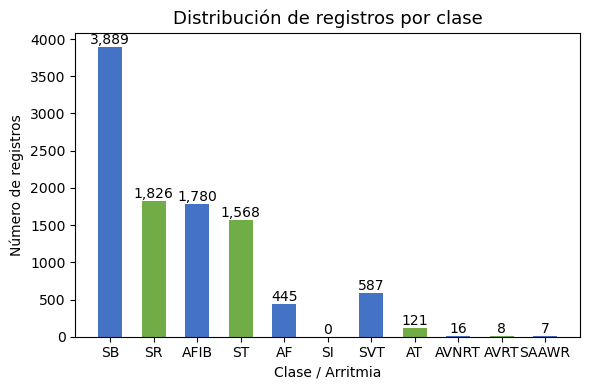

In [50]:

# TABLA CON CARACTERÍSTICAS GENERALES DEL DATASET
# ============================================================

# Se crea un DataFrame que contiene las principales
# características generales del conjunto de datos.
# La primera columna contiene el nombre de cada característica
# y la segunda columna contiene su valor correspondiente.

tabla_general = pd.DataFrame({
    "Característica": [
        "Total de registros",
        "Total de sujetos",
        "Número de canales",
        "Derivaciones",
        "Frecuencia de muestreo",
        "Duración de cada registro"
    ],
    
    "Valor": [
        "10.646",
        "10.646",
        "12",
        "I, II, III, aVR, aVL, aVF, V1–V6",
        "500 Hz",
        "10 s"
    ]
})


# Se muestra la tabla aplicando diferentes estilos para
# mejorar su presentación.

display(
    tabla_general.style
    .hide(axis="index")
    .set_caption("Características generales del conjunto de datos")
    .set_properties(**{
        "text-align": "left",
        "padding": "5px"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("margin-bottom", "8px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#4472C4"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border", "1px solid #D9E2F3")
            ]
        }
    ])
)



# TABLA CON LA DISTRIBUCIÓN DE LAS CLASES
# ============================================================

# Se crea un DataFrame con las diferentes clases o ritmos
# presentes en los registros analizados.
# "Registros" indica cuántos registros pertenecen a cada clase.
# "Sujetos" indica cuántos sujetos pertenecen a cada clase.

tabla_clases = pd.DataFrame({
    "Clase / Arritmia": ["SB", "SR", "AFIB", "ST", "AF", "SI", "SVT", "AT", "AVNRT", "AVRT", "SAAWR"],
    "Registros": [3889, 1826, 1780, 1568, 445, 0, 587, 121, 16, 8, 7],
    "Sujetos": [3889, 1826, 1780, 1568, 445, 0, 587, 121, 16, 8, 7]
})


# Se calcula el porcentaje que representa cada clase respecto
# al total de 10.646 registros.
# El resultado se multiplica por 100 para expresarlo como
# porcentaje y se redondea a dos cifras decimales.

tabla_clases["Porcentaje"] = (
    tabla_clases["Registros"] / 10646 * 100
).round(2)


# Se muestra la tabla de distribución aplicando formato.

display(
    tabla_clases.style
    .hide(axis="index")
    .set_caption("Distribución de las clases analizadas")
    .format({"Porcentaje": "{:.2f} %"})
    .set_properties(**{
        "text-align": "center",
        "padding": "5px"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("margin-bottom", "8px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#70AD47"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border", "1px solid #E2F0D9")
            ]
        }
    ])
)



# GRÁFICO DE DISTRIBUCIÓN DE LAS CLASES
# ============================================================
# Se crea una figura para mostrar gráficamente la cantidad de registros de cada clase.

plt.figure(figsize=(6, 4))


# Se crea un gráfico de barras.
# En el eje X se colocan las diferentes clases.
# En el eje Y se coloca el número de registros.
# "color" define el color de las barras.
# "width" controla el ancho de las barras.

barras = plt.bar(
    tabla_clases["Clase / Arritmia"],
    tabla_clases["Registros"],
    color=["#4472C4", "#70AD47"],
    width=0.55
)


# Se establece el título y los nombres de los ejes.

plt.title("Distribución de registros por clase", fontsize=13)
plt.xlabel("Clase / Arritmia")
plt.ylabel("Número de registros")



# MOSTRAR EL NÚMERO DE REGISTROS SOBRE CADA BARRA
# ============================================================

# Se recorre cada barra del gráfico para obtener su altura,
# que corresponde al número de registros de esa clase.
for barra in barras:

    # Obtiene la altura de la barra.
    altura = barra.get_height()


    # Coloca el número de registros encima de cada barra.
    # barra.get_x() obtiene la posición horizontal de la barra.
    # barra.get_width() obtiene su ancho.
    # int(altura) convierte el valor a entero.
    # :, permite mostrar los números con separador de miles.

    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        f"{int(altura):,}",
        ha="center",
        va="bottom"
    )


# Ajusta automáticamente los espacios del gráfico para evitar
# que los elementos queden cortados.
plt.tight_layout()

# Muestra el gráfico.
plt.show()


#### **Metadata de los pacientes con sus respectivas arritmias**

Para este caso se trabajaran con dos condiciones 
- SB Sinus Bradycardia
- ST  Taquicardia sinusal

In [ ]:
#Extrapolado a todos los pacientes con la condicion de SB

# ============================================================
#  ORGANIZAR LOS METADATOS DE TODOS LOS PACIENTES SB
# ============================================================


subject_meta = diagnostics[
    diagnostics["FileName"].astype(str).isin(FILENAME_SB)
].copy()


# Reiniciar los índices
subject_meta = subject_meta.reset_index(drop=True)


# Mostrar la tabla completa
subject_meta

,FileName,Rhythm,Beat,PatientAge,Gender,VentricularRate,AtrialRate,QRSDuration,QTInterval,QTCorrected,RAxis,TAxis,QRSCount,QOnset,QOffset,TOffset
0,MUSE_20180112_073319_29000,SB,TWC,59,FEMALE,52,52,92,432,401,76,42,8,215,261,431
1,MUSE_20180113_121940_44000,SB,NONE,66,MALE,53,53,96,456,427,34,3,9,219,267,447
2,MUSE_20180112_120347_79000,SB,NONE,46,FEMALE,57,57,70,404,393,38,24,9,225,260,427
3,MUSE_20180114_075128_92000,SB,NONE,45,MALE,59,59,84,390,386,78,68,10,218,260,413
4,MUSE_20180118_174026_42000,SB,NONE,47,FEMALE,58,58,80,420,412,80,48,10,212,252,422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3884,MUSE_20180114_070348_17000,SB,RBBB,62,MALE,55,55,124,440,420,48,28,9,221,283,441
3885,MUSE_20180114_134724_10000,SB,LVHV,56,FEMALE,56,56,88,444,428,49,62,9,219,263,441
3886,MUSE_20180113_122544_20000,SB,NONE,38,FEMALE,56,56,88,434,418,69,54,10,218,262,435
3887,MUSE_20180114_074720_85000,SB,NONE,55,FEMALE,57,57,94,414,402,-4,1,10,212,259,419


In [ ]:
#Extrapolado a todos los pacientes con la condicion de ST

# ============================================================
#  ORGANIZAR LOS METADATOS DE TODOS LOS PACIENTES ST
# ============================================================


subject_meta = diagnostics[
    diagnostics["FileName"].astype(str).isin(FILENAME_ST)
].copy()


subject_meta = subject_meta.reset_index(drop=True)

subject_meta

,FileName,Rhythm,Beat,PatientAge,Gender,VentricularRate,AtrialRate,QRSDuration,QTInterval,QTCorrected,RAxis,TAxis,QRSCount,QOnset,QOffset,TOffset
0,MUSE_20180113_135023_96000,ST,NONE,77,MALE,120,120,70,306,432,39,28,20,225,260,378
1,MUSE_20180116_170254_89000,ST,TWC,64,FEMALE,113,113,74,338,463,-5,247,19,219,256,388
2,MUSE_20180114_121405_34000,ST,NONE,36,MALE,107,107,76,314,419,73,53,18,228,266,385
3,MUSE_20180119_173922_99000,ST,VPB,65,FEMALE,105,105,78,312,412,-3,16,18,228,267,384
4,MUSE_20180113_131104_16000,ST,LVQRSCL,86,FEMALE,113,113,86,344,471,62,95,18,213,256,385
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1563,MUSE_20180111_160732_85000,ST,NONE,56,MALE,103,103,82,334,437,63,35,17,226,267,393
1564,MUSE_20180118_172259_80000,ST,VPB,62,FEMALE,104,104,98,362,476,36,31,17,211,260,392
1565,MUSE_20180118_173429_16000,ST,RBBB,39,FEMALE,107,107,112,370,493,74,40,18,225,281,410
1566,MUSE_20180113_171345_85000,ST,LVQRSLL TWC VPB,91,FEMALE,102,102,78,394,513,71,-11,16,220,259,417


#### **Señales ECG**

- Señales ECG para SB

In [34]:
# ============================================================
# EXTRACCION SEÑALES PARA SB
# ============================================================

# Se crea un diccionario vacío donde se guardará la información
# de cada ECG.
# Cada archivo quedará almacenado utilizando su nombre como clave

ECG_SB = {}


# FILENAME_SB contiene los nombres de los archivos que
# corresponden a los registros SB.

# 'i' es un contador que empieza en 1 y 'filename' es el
# nombre del archivo que se está procesando.

for i, filename in enumerate(FILENAME_SB, start=1):

    # Asegurar que el nombre sea texto y eliminar espacios
    filename = str(filename).strip()


    # Si el nombre no termina en ".csv", se agrega automáticamente.
    if not filename.lower().endswith(".csv"):
        filename += ".csv"

    
    # SIGNALS_DIR corresponde a la carpeta donde están
    # almacenados los archivos ECG
    signal_path = SIGNALS_DIR / filename


  
    # Si el archivo no existe, se muestra una advertencia
    # y se continúa con el siguiente archivo.
    if not signal_path.is_file():

        print(f"No encontrado: {filename}")

        continue

    # Leer ÚNICAMENTE el canal 2
    # usecols=[1] indica que solo se debe leer la segunda
    # columna del archivo.
    ecg_signal = pd.read_csv(
        signal_path,
        header=None,
        usecols=[1],
        names=["Canal_2"]
    )


   
    # Obtener el número de muestras
    # len() cuenta cuántas muestras contiene el canal 2.
    n_samples = len(ecg_signal)


    # Crear el vector de tiempo
    # Cada muestra está separada por 1/FS segundos.
    # Si FS = 500 Hz:
    #     Δt = 1 / 500 = 0.002 segundos
    # Por lo tanto, se genera un tiempo correspondiente
    # para cada muestra del ECG.

    t = np.arange(n_samples) / FS



    # Guardar la información del ECG
    # Para cada archivo se almacenan:
    # Signal     → valores del canal 2
    # Time       → tiempo correspondiente a cada muestra
    # n_samples  → cantidad de muestras del registro

    ECG_SB[filename] = {

        "Signal": ecg_signal,

        "Time": t,

        "n_samples": n_samples
    }


    
    # Esto permite saber cuánto ha avanzado el procesamiento
    # cuando se tienen muchos registros.
    # Imprime cada se ha procesado 1000 archivos
    if i % 1000 == 0:

        print(
            f"Procesados: {i}/{len(FILENAME_SB)}"
        )



# RESUMEN DEL PROCESAMIENTO

print("\n==========================================")
print("PROCESAMIENTO FINALIZADO")
print("==========================================")

# Número total de archivos que se intentaron procesar.
print(
    f"Archivos solicitados : {len(FILENAME_SB)}"
)

# Número de archivos que realmente pudieron ser cargados.
print(
    f"ECG cargados         : {len(ECG_SB)}"
)


#Se verifican dos datos para confirmar su apropiado alamcenamiento
#Para este caso, se hace con los dos pacientes a usar, el paciente 4 y el 8

# Esto permite comprobar que diferentes archivos fueron
# cargados correctamente y que contienen el canal 2.
indices_verificar = [4, 8]


for indice in indices_verificar:

    # Verificar que exista ese paciente dentro de los
    # archivos que fueron cargados.

    if indice <= len(FILENAME_SB):

        nombre_archivo = str(
            FILENAME_SB[indice - 1]
        ).strip()


        # Agregar ".csv" si es necesario.
        if not nombre_archivo.lower().endswith(".csv"):
            nombre_archivo += ".csv"


        # Comprobar que ese archivo haya sido cargado
        # correctamente en el diccionario.
        if nombre_archivo in ECG_SB:

            print("\n------------------------------------------")
            print(f"Paciente / registro #{indice}")
            print(f"Archivo: {nombre_archivo}")
            print("------------------------------------------")

            print(
                f"Número de muestras: "
                f"{ECG_SB[nombre_archivo]['n_samples']}"
            )

            print("\nMuestras del Canal 2:")

            display(
                ECG_SB[nombre_archivo]["Signal"].head()
            )

        else:

            print(
                f"\nEl registro #{indice} "
                f"no fue cargado: {nombre_archivo}"
            )

    else:

        print(
            f"\nNo existe un registro número {indice} "
            f"en FILENAME_SB."
        )


Procesados: 1000/3889
Procesados: 2000/3889
Procesados: 3000/3889

PROCESAMIENTO FINALIZADO
Archivos solicitados : 3889
ECG cargados         : 3889

------------------------------------------
Paciente / registro #4
Archivo: MUSE_20180114_075128_92000.csv
------------------------------------------
Número de muestras: 5000

Muestras del Canal 2:


,Canal_2
0,2.3965
1,9.4703
2,15.3960
3,19.4890
4,21.7330



------------------------------------------
Paciente / registro #8
Archivo: MUSE_20180114_070718_20000.csv
------------------------------------------
Número de muestras: 5000

Muestras del Canal 2:


,Canal_2
0,22.8700
1,15.8580
2,10.0790
3,6.5347
4,5.6674


- Señales ECG para ST

In [35]:
# ============================================================
# EXTRACCION SEÑALES PARA ST
# ============================================================

# Se crea un diccionario vacío donde se guardará la información
# de cada ECG.
# Cada archivo quedará almacenado utilizando su nombre como clave

ECG_ST = {}


# FILENAME_SB contiene los nombres de los archivos que
# corresponden a los registros SB.

# 'i' es un contador que empieza en 1 y 'filename' es el
# nombre del archivo que se está procesando.

for i, filename in enumerate(FILENAME_ST, start=1):

    # Asegurar que el nombre sea texto y eliminar espacios
    filename = str(filename).strip()


    # Si el nombre no termina en ".csv", se agrega automáticamente.
    if not filename.lower().endswith(".csv"):
        filename += ".csv"

    
    # SIGNALS_DIR corresponde a la carpeta donde están
    # almacenados los archivos ECG
    signal_path = SIGNALS_DIR / filename


  
    # Si el archivo no existe, se muestra una advertencia
    # y se continúa con el siguiente archivo.
    if not signal_path.is_file():

        print(f"No encontrado: {filename}")

        continue

    # Leer ÚNICAMENTE el canal 2
    # usecols=[1] indica que solo se debe leer la segunda
    # columna del archivo.
    ecg_signal = pd.read_csv(
        signal_path,
        header=None,
        usecols=[1],
        names=["Canal_2"]
    )


   
    # Obtener el número de muestras
    # len() cuenta cuántas muestras contiene el canal 2.
    n_samples = len(ecg_signal)


    # Crear el vector de tiempo
    # Cada muestra está separada por 1/FS segundos.
    # Si FS = 500 Hz:
    #     Δt = 1 / 500 = 0.002 segundos
    # Por lo tanto, se genera un tiempo correspondiente
    # para cada muestra del ECG.

    t = np.arange(n_samples) / FS



    # Guardar la información del ECG
    # Para cada archivo se almacenan:
    # Signal     → valores del canal 2
    # Time       → tiempo correspondiente a cada muestra
    # n_samples  → cantidad de muestras del registro

    ECG_ST[filename] = {

        "Signal": ecg_signal,

        "Time": t,

        "n_samples": n_samples
    }


    
    # Esto permite saber cuánto ha avanzado el procesamiento
    # cuando se tienen muchos registros.
    # Imprime cada se ha procesado 1000 archivos
    if i % 1000 == 0:

        print(
            f"Procesados: {i}/{len(FILENAME_ST)}"
        )



# RESUMEN DEL PROCESAMIENTO

print("\n==========================================")
print("PROCESAMIENTO FINALIZADO")
print("==========================================")

# Número total de archivos que se intentaron procesar.
print(
    f"Archivos solicitados : {len(FILENAME_ST)}"
)

# Número de archivos que realmente pudieron ser cargados.
print(
    f"ECG cargados         : {len(ECG_ST)}"
)


#Se verifican dos datos para confirmar su apropiado alamcenamiento
#Para este caso, se hace con los dos pacientes a usar, el paciente 4 y el 8

# Esto permite comprobar que diferentes archivos fueron
# cargados correctamente y que contienen el canal 2.
indices_verificar = [4, 8]


for indice in indices_verificar:

    # Verificar que exista ese paciente dentro de los
    # archivos que fueron cargados.

    if indice <= len(FILENAME_ST):

        nombre_archivo = str(
            FILENAME_ST[indice - 1]
        ).strip()


        # Agregar ".csv" si es necesario.
        if not nombre_archivo.lower().endswith(".csv"):
            nombre_archivo += ".csv"


        # Comprobar que ese archivo haya sido cargado
        # correctamente en el diccionario.
        if nombre_archivo in ECG_ST:

            print("\n------------------------------------------")
            print(f"Paciente / registro #{indice}")
            print(f"Archivo: {nombre_archivo}")
            print("------------------------------------------")

            print(
                f"Número de muestras: "
                f"{ECG_ST[nombre_archivo]['n_samples']}"
            )

            print("\nMuestras del Canal 2:")

            display(
                ECG_ST[nombre_archivo]["Signal"].head()
            )

        else:

            print(
                f"\nEl registro #{indice} "
                f"no fue cargado: {nombre_archivo}"
            )

    else:

        print(
            f"\nNo existe un registro número {indice} "
            f"en FILENAME_SB."
        )


Procesados: 1000/1568

PROCESAMIENTO FINALIZADO
Archivos solicitados : 1568
ECG cargados         : 1568

------------------------------------------
Paciente / registro #4
Archivo: MUSE_20180119_173922_99000.csv
------------------------------------------
Número de muestras: 5000

Muestras del Canal 2:


,Canal_2
0,737.71
1,749.05
2,764.37
3,786.42
4,816.01



------------------------------------------
Paciente / registro #8
Archivo: MUSE_20180116_171134_36000.csv
------------------------------------------
Número de muestras: 5000

Muestras del Canal 2:


,Canal_2
0,-16.348
1,-15.667
2,-15.107
3,-14.820
4,-14.985


#### **Visualización de la señal**

- Para SB

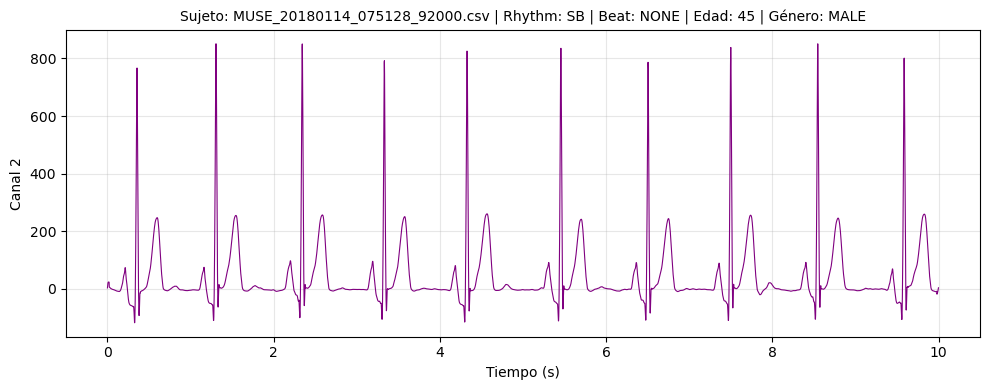

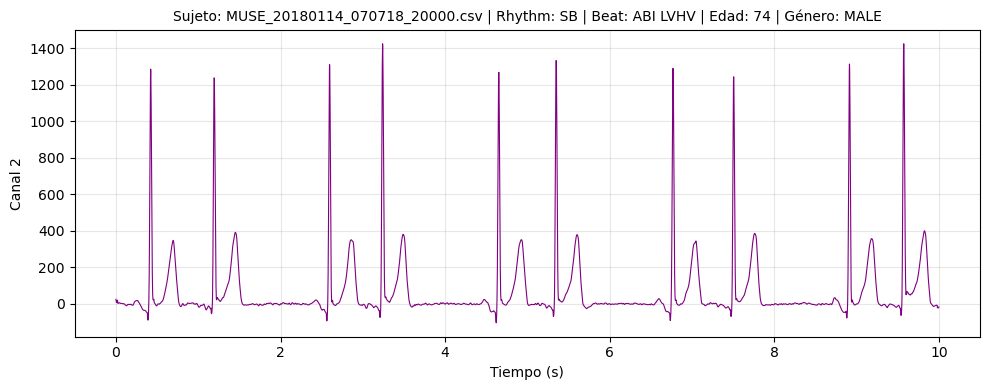

In [ ]:
# ============================================================
# GRAFICAR LOS REGISTROS SB PARA DOS PACIENTES
# ============================================================

# ECG_SB contiene todos los ECG que fueron cargados anteriormente.
# Por eso seleccionamos estos dos registros.

subject_files = [
    list(ECG_SB.keys())[3],
    list(ECG_SB.keys())[7]
]


# Se procesa cada uno de los dos archivos seleccionados.
# 'fname' contiene el nombre del archivo.

for i, fname in enumerate(subject_files, start=1):

    # Se busca en 'diagnostics' la información correspondiente
    # al archivo que estamos procesando.
    # Path(fname).stem elimina la extensión ".csv" del nombre.
    meta = diagnostics[
        diagnostics["FileName"] == Path(fname).stem
    ].reset_index(drop=True)


    
    # 'Signal' contiene únicamente los valores del CANAL 2,
    # ya que en el código anterior solo cargamos este
    # 'Time' contiene el instante de tiempo correspondiente
    # a cada muestra del ECG.

    sig = ECG_SB[fname]["Signal"]

    t_sub = ECG_SB[fname]["Time"]


   
    # Se extraen algunos datos de los metadatos para
    # mostrarlos posteriormente en el título del gráfico.

    rhythm = meta.loc[0, "Rhythm"]

    beat = meta.loc[0, "Beat"]

    age = meta.loc[0, "PatientAge"]

    gender = meta.loc[0, "Gender"]


   
    # Se crea una figura independiente para cada paciente.

    plt.figure(figsize=(10, 4))


    
    # Se representa la amplitud del Canal 2 en función del tiempo.
    
    plt.plot(
        t_sub,
        sig["Canal_2"],
        linewidth=0.8,
        color="purple"
    )
    # Eje vertical: amplitud de la señal del ECG.
    plt.ylabel("Canal 2")

    # Eje horizontal: tiempo en segundos.
    plt.xlabel("Tiempo (s)")

    # Agregar una cuadrícula para facilitar la visualización.
    plt.grid(True, alpha=0.3)

    # Se muestra el nombre del registro junto con algunos
    # de sus metadatos.
    plt.title(
        f"Sujeto: {fname} | "
        f"Rhythm: {rhythm} | "
        f"Beat: {beat} | "
        f"Edad: {age} | "
        f"Género: {gender}",
        fontsize=10
    )

    plt.tight_layout()

    # Mostrar el gráfico.
    plt.show()


- Para ST

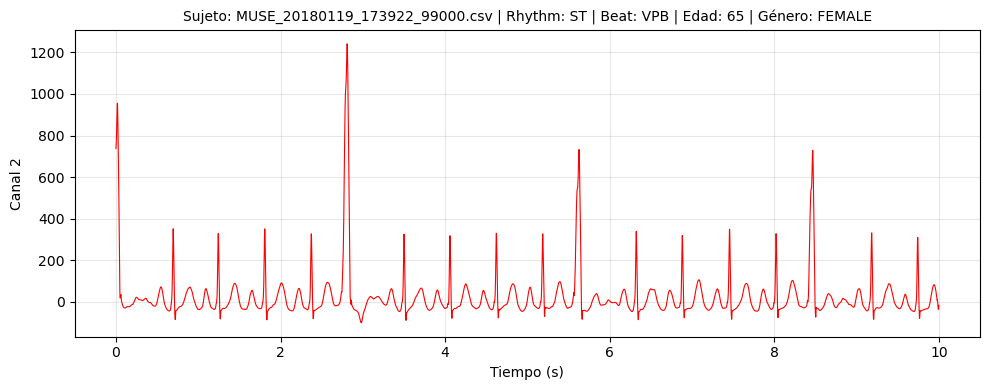

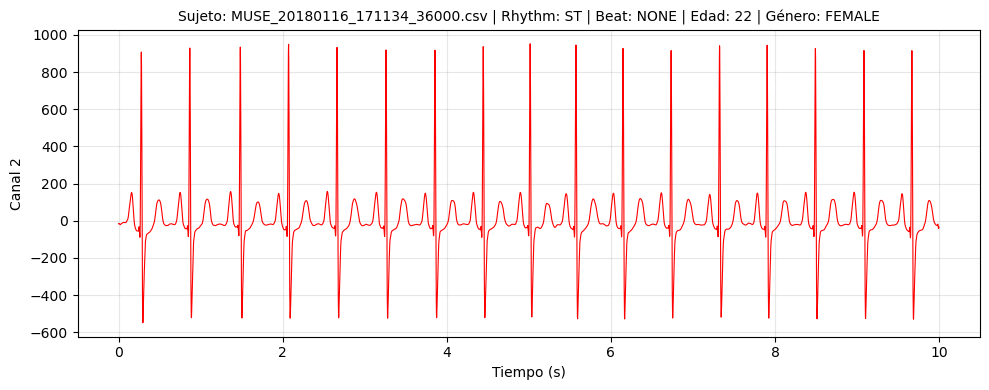

In [36]:
# ============================================================
# GRAFICAR LOS REGISTROS ST PARA DOS PACIENTES
# ============================================================

# ECG_SB contiene todos los ECG que fueron cargados anteriormente.
# Por eso seleccionamos estos dos registros.

subject_files = [
    list(ECG_ST.keys())[3],
    list(ECG_ST.keys())[7]
]


# Se procesa cada uno de los dos archivos seleccionados.
# 'fname' contiene el nombre del archivo.

for i, fname in enumerate(subject_files, start=1):

    # Se busca en 'diagnostics' la información correspondiente
    # al archivo que estamos procesando.
    # Path(fname).stem elimina la extensión ".csv" del nombre.
    meta = diagnostics[
        diagnostics["FileName"] == Path(fname).stem
    ].reset_index(drop=True)


    
    # 'Signal' contiene únicamente los valores del CANAL 2,
    # ya que en el código anterior solo cargamos este
    # 'Time' contiene el instante de tiempo correspondiente
    # a cada muestra del ECG.

    sig = ECG_ST[fname]["Signal"]

    t_sub = ECG_ST[fname]["Time"]


   
    # Se extraen algunos datos de los metadatos para
    # mostrarlos posteriormente en el título del gráfico.

    rhythm = meta.loc[0, "Rhythm"]

    beat = meta.loc[0, "Beat"]

    age = meta.loc[0, "PatientAge"]

    gender = meta.loc[0, "Gender"]


   
    # Se crea una figura independiente para cada paciente.

    plt.figure(figsize=(10, 4))


    
    # Se representa la amplitud del Canal 2 en función del tiempo.
    
    plt.plot(
        t_sub,
        sig["Canal_2"],
        linewidth=0.8,
        color="red"
    )
    # Eje vertical: amplitud de la señal del ECG.
    plt.ylabel("Canal 2")

    # Eje horizontal: tiempo en segundos.
    plt.xlabel("Tiempo (s)")

    # Agregar una cuadrícula para facilitar la visualización.
    plt.grid(True, alpha=0.3)

    # Se muestra el nombre del registro junto con algunos
    # de sus metadatos.
    plt.title(
        f"Sujeto: {fname} | "
        f"Rhythm: {rhythm} | "
        f"Beat: {beat} | "
        f"Edad: {age} | "
        f"Género: {gender}",
        fontsize=10
    )

    plt.tight_layout()

    # Mostrar el gráfico.
    plt.show()


#### **Box plot**
Concentracion de arritmias con base a al edad 


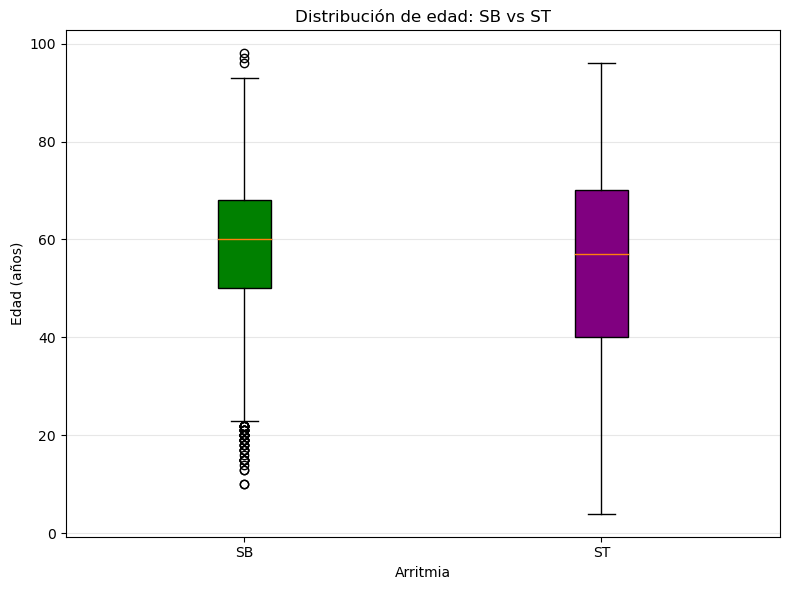

Pacientes SB: 3889
Pacientes ST: 1568


In [51]:
# LISTAS PARA GUARDAR LAS EDADES
edad_SB = []
edad_ST = []


# OBTENER EDADES DE LOS PACIENTES SB
for filename in FILENAME_SB:

    nombre = Path(str(filename)).stem

    meta = diagnostics[
        diagnostics["FileName"] == nombre
    ]

    if not meta.empty:
        edad = meta.iloc[0]["PatientAge"]

        if pd.notna(edad):
            edad_SB.append(edad)


# OBTENER EDADES DE LOS PACIENTES ST
for filename in FILENAME_ST:

    nombre = Path(str(filename)).stem

    meta = diagnostics[
        diagnostics["FileName"] == nombre
    ]

    if not meta.empty:
        edad = meta.iloc[0]["PatientAge"]

        if pd.notna(edad):
            edad_ST.append(edad)


# CREAR EL BOXPLOT
plt.figure(figsize=(8, 6))

box = plt.boxplot(
    [edad_SB, edad_ST],
    labels=["SB", "ST"],
    patch_artist=True
)

box["boxes"][0].set_facecolor("green")   # SB
box["boxes"][1].set_facecolor("purple")     # ST

plt.xlabel("Arritmia")
plt.ylabel("Edad (años)")

plt.title("Distribución de edad: SB vs ST")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# MOSTRAR CUÁNTOS PACIENTES HAY EN CADA GRUPO
print("Pacientes SB:", len(edad_SB))
print("Pacientes ST:", len(edad_ST))